# Visualizing logical_consistency as a claim graph

`logical_consistency` scores a hypothesis via Dung's grounded-extension
semantics: claims are nodes, a judge-detected contradiction between two claims
is a symmetric "attack" edge, and a claim survives (is IN the grounded
extension) only if every claim attacking it is itself defeated. The score is
just `|survivors| / |claims|` -- but that single number tells you nothing
about *why* a claim survived or got excluded. This notebook draws the actual
graph so you can see it directly: a mutual contradiction with nothing else
around it excludes *both* claims (neither can be prioritized over the other);
a claim attacked only by an already-excluded claim survives, defended.

Everything here is read straight from the real metric's own `evidence` dict
(`LogicalConsistency().score(...)`) -- nothing about the graph structure is
recomputed or reimplemented, so this can never drift from what the metric
actually does.


In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "benchmarking_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import networkx as nx

from benchmarking_pipeline.axes.accuracy.logical_consistency import LogicalConsistency
from benchmarking_pipeline.core.config import RunConfig
from benchmarking_pipeline.core.context import Context
from benchmarking_pipeline.core.models import EvaluationRun, Tool
from benchmarking_pipeline.io.parsers import parse_json
from benchmarking_pipeline.services.llm_judge import OpenAIJudge

# --- Config ---
CAPTURE_PATH = "data/captures/dmri_extracted.json"
HYPOTHESIS_RANK = 4  # this one has real, known contradiction structure -- see the writeup
JUDGE_MODEL = "gpt-4o-mini"  # deliberately the weaker judge here -- see the markdown cell below

hyps = parse_json(CAPTURE_PATH).hypotheses
hyp = next(h for h in hyps if h.rank == HYPOTHESIS_RANK)
print(f"H{hyp.rank}: {hyp.text}")
print(f"{len(hyp.claims)} claims")


H4: Cross-tissue transfer of the model posterior via meta-learning on the compartment-library structure
8 claims


## Run the real metric

This is the actual `LogicalConsistency` metric -- same class the pipeline
registers and scores every hypothesis with. Nothing below is a stand-in.

**Why `gpt-4o-mini` by default:** this session found that `gpt-4o-mini`
sometimes still misreads a "gap in current practice vs. what the proposed
method does instead" claim pair as a contradiction, even after the judge
instructions were fixed to explicitly rule that out -- `gpt-4.1` gets it right
consistently, `gpt-4o-mini` doesn't. Hypothesis 4 here is a real example of
that gap: try changing `JUDGE_MODEL` to `"gpt-4.1"` above and re-running --
the same hypothesis comes back fully coherent, no contradictions at all.


In [2]:
judge = OpenAIJudge(JUDGE_MODEL)
run = EvaluationRun(tool=Tool(name="notebook"), prompt="", outputs=parse_json(CAPTURE_PATH))
ctx = Context(config=RunConfig(), judge=judge)

result = LogicalConsistency().score(hyp, run, ctx)
print(f"score: {result.score} ({result.anchor})")
print()
for i, (claim, role) in enumerate(zip(hyp.claims, result.evidence["roles"])):
    print(f"C{i} [{role}]: {claim.text}")


score: 0.25 (incoherent)

C0 [premise]: PRISM and SBMI are trained per model family and amortized across voxels/datasets, but they do not transfer across tissue types with different compartment libraries.
C1 [premise]: Transfer learning in diffusion MRI exists but transfers parameters or reconstruction priors, not the model-selection posterior itself.
C2 [premise]: For a new tissue type, you currently retrain from scratch; no work meta-learns a prior over compartment-library structure such that a few measurements from a new tissue type rapidly localize the model posterior.
C3 [mechanistic_step]: The compartment library can be treated as a shared structure across tissue types, and one can meta-learn an initialization of the PRISM-style encoder-decoder such that, given a small calibration scan from a new tissue type, the model posterior adapts with few gradient steps (MAML/Reptile-style) or few-shot conditioning.
C4 [mechanistic_step]: The meta-training distribution spans multiple tissue

## Draw the claim graph

- **Node color** = survival status under the grounded extension: green = IN
  (survives), red = OUT (defeated by a surviving attacker), gray = UNDEC
  (part of a contradiction with no external defender either way -- genuinely
  undecidable, not a bug, and does not count as surviving)
- **Node shape** = role (circle = premise/background, square = mechanistic
  step/prediction -- the "core argument" roles a contradiction hurts most)
- **Solid red edge** = judge-detected contradiction (undirected -- the
  relation is inherently symmetric)
- **Dashed blue arrow** = entailment (A implies B), used only for orphan
  detection, not for scoring
- **Dashed node border** = orphan: a mechanistic step or prediction with
  nothing entailing it


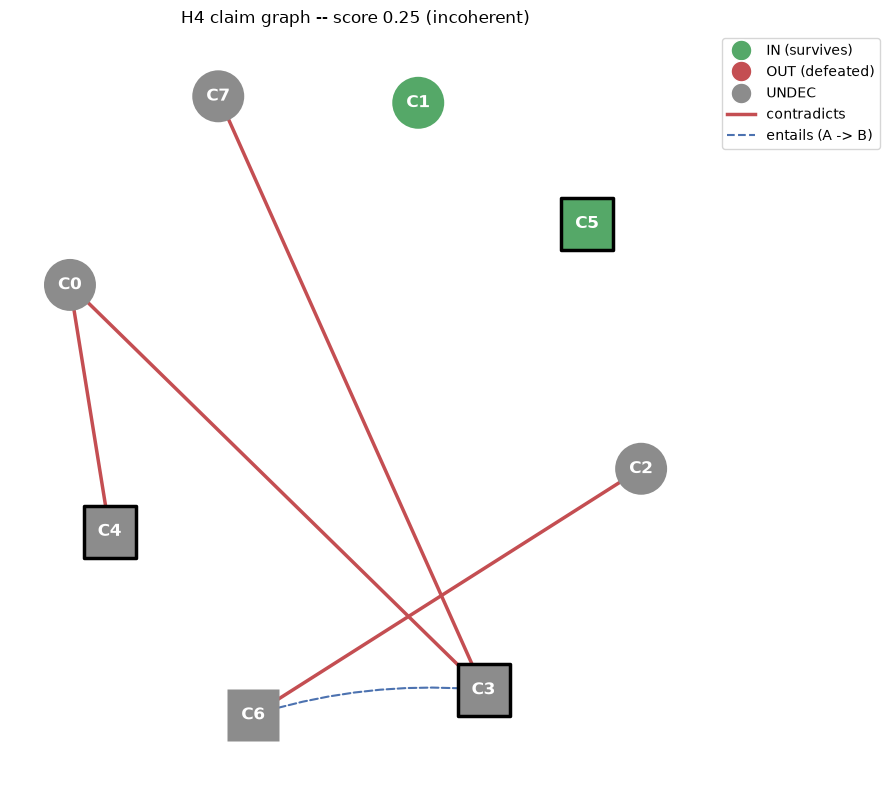

In [3]:
ev = result.evidence
n = ev["n_claims"]
roles = ev["roles"]
in_set = set(ev["consistent_claim_indices"])
out_set = set(ev["out_claim_indices"])
undec_set = set(ev["undecided_claim_indices"])
orphans = set(ev["orphan_claim_indices"])

G = nx.Graph()
G.add_nodes_from(range(n))
contradiction_edges = [(e["i"], e["j"]) for e in ev["edges_checked"] if e["verdict"] == "contradicts"]
entailment_edges = [
    (e["i"], e["j"]) if e["verdict"] == "a_entails_b" else (e["j"], e["i"])
    for e in ev["edges_checked"] if e["verdict"] in ("a_entails_b", "b_entails_a")
]

status_color = {}
for i in range(n):
    if i in in_set:
        status_color[i] = "#55A868"   # green -- survives
    elif i in out_set:
        status_color[i] = "#C44E52"   # red -- defeated
    else:
        status_color[i] = "#8C8C8C"   # gray -- undecided

CORE_ROLES = {"mechanistic_step", "prediction"}
node_shapes = {i: ("s" if roles[i] in CORE_ROLES else "o") for i in range(n)}

pos = nx.spring_layout(G, seed=7, k=1.2)

fig, ax = plt.subplots(figsize=(9, 8))
for shape in ("o", "s"):
    nodes = [i for i in range(n) if node_shapes[i] == shape]
    if not nodes:
        continue
    linewidths = [2.5 if i in orphans else 1.0 for i in nodes]
    edgecolors = ["black" if i in orphans else "none" for i in nodes]
    nx.draw_networkx_nodes(
        G, pos, nodelist=nodes, node_shape=shape, node_size=1400, ax=ax,
        node_color=[status_color[i] for i in nodes],
        linewidths=linewidths, edgecolors=edgecolors,
    )
nx.draw_networkx_labels(G, pos, labels={i: f"C{i}" for i in range(n)}, ax=ax, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, edgelist=contradiction_edges, ax=ax, edge_color="#C44E52", width=2.5)
nx.draw_networkx_edges(
    G, pos, edgelist=entailment_edges, ax=ax, edge_color="#4C72B0", width=1.5,
    style="dashed", arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.1",
)

legend_elements = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#55A868", markersize=15, label="IN (survives)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#C44E52", markersize=15, label="OUT (defeated)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#8C8C8C", markersize=15, label="UNDEC"),
    plt.Line2D([0], [0], color="#C44E52", lw=2.5, label="contradicts"),
    plt.Line2D([0], [0], color="#4C72B0", lw=1.5, ls="--", label="entails (A -> B)"),
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1))
ax.set_title(f"H{hyp.rank} claim graph -- score {result.score} ({result.anchor})")
ax.axis("off")
plt.tight_layout()
plt.show()


## Why each claim ended up where it did

Severity (how much a contradiction should worry a reviewer) is diagnostic
only -- it never changes the score, but it tells you which contradictions are
worth a human looking at first.


In [4]:
if ev["contradiction_pairs"]:
    print("Contradictions found:")
    for pair in ev["contradiction_pairs"]:
        print(f"  [{pair['severity']}] C{pair['i']} <--> C{pair['j']}")
        print(f"      C{pair['i']}: {pair['claim_i']}")
        print(f"      C{pair['j']}: {pair['claim_j']}")
        print()
else:
    print("No contradictions found -- fully coherent.")

if ev["orphan_claim_indices"]:
    print("Orphan claims (mechanistic_step/prediction with nothing entailing them):")
    for i in ev["orphan_claim_indices"]:
        print(f"  C{i} [{roles[i]}]: {hyp.claims[i].text}")

if ev["n_pairs_skipped_due_to_budget"]:
    print(f"\n{ev['n_pairs_skipped_due_to_budget']} lowest-priority pair(s) skipped due to logical_consistency_max_pairs.")


Contradictions found:
  [high] C0 <--> C3
      C0: PRISM and SBMI are trained per model family and amortized across voxels/datasets, but they do not transfer across tissue types with different compartment libraries.
      C3: The compartment library can be treated as a shared structure across tissue types, and one can meta-learn an initialization of the PRISM-style encoder-decoder such that, given a small calibration scan from a new tissue type, the model posterior adapts with few gradient steps (MAML/Reptile-style) or few-shot conditioning.

  [high] C0 <--> C4
      C0: PRISM and SBMI are trained per model family and amortized across voxels/datasets, but they do not transfer across tissue types with different compartment libraries.
      C4: The meta-training distribution spans multiple tissue types' compartment configurations (e.g., WM, GM, muscle, liver, prostate—each with different dominant compartments), so the network learns a 'prior over compartment-combination structure' that